1. **ANALYSE DU DATASET**

ANALYSE DU DATASET PROFESSEUR

✅ Dataset trouvé : /kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images

📁 STRUCTURE DU DATASET
------------------------------------------------------------
📁 facesDataset/ (30571 items)
  📄 0000000.png (0.02 MB)
  📄 0000001.png (0.02 MB)
  📄 0000002.png (0.02 MB)
  📄 0000003.png (0.03 MB)
  📄 0000004.png (0.03 MB)
  📄 0000005.png (0.02 MB)
  📄 0000006.png (0.03 MB)
  📄 0000007.png (0.02 MB)
  📄 0000008.png (0.02 MB)
  📄 0000009.png (0.03 MB)
  📄 0000010.png (0.02 MB)
  📄 0000011.png (0.02 MB)
  📄 0000012.png (0.03 MB)
  📄 0000013.png (0.03 MB)
  📄 0000014.png (0.03 MB)
  📄 0000015.png (0.03 MB)
  📄 0000016.png (0.02 MB)
  📄 0000017.png (0.03 MB)
  📄 0000018.png (0.02 MB)
  📄 0000019.png (0.03 MB)
  ... et 30551 autres items
📁 facesDataset_masked/ (24678 items)
  📄 0000000_surgical_green.png (0.03 MB)
  📄 0000001_inpaint.png (0.03 MB)
  📄 0000002_empty.png (0.02 MB)
  📄 0000003_surgical_green.png (0.03 MB)
  📄 0000004_cloth.png (0.03 MB)
  📄 0000

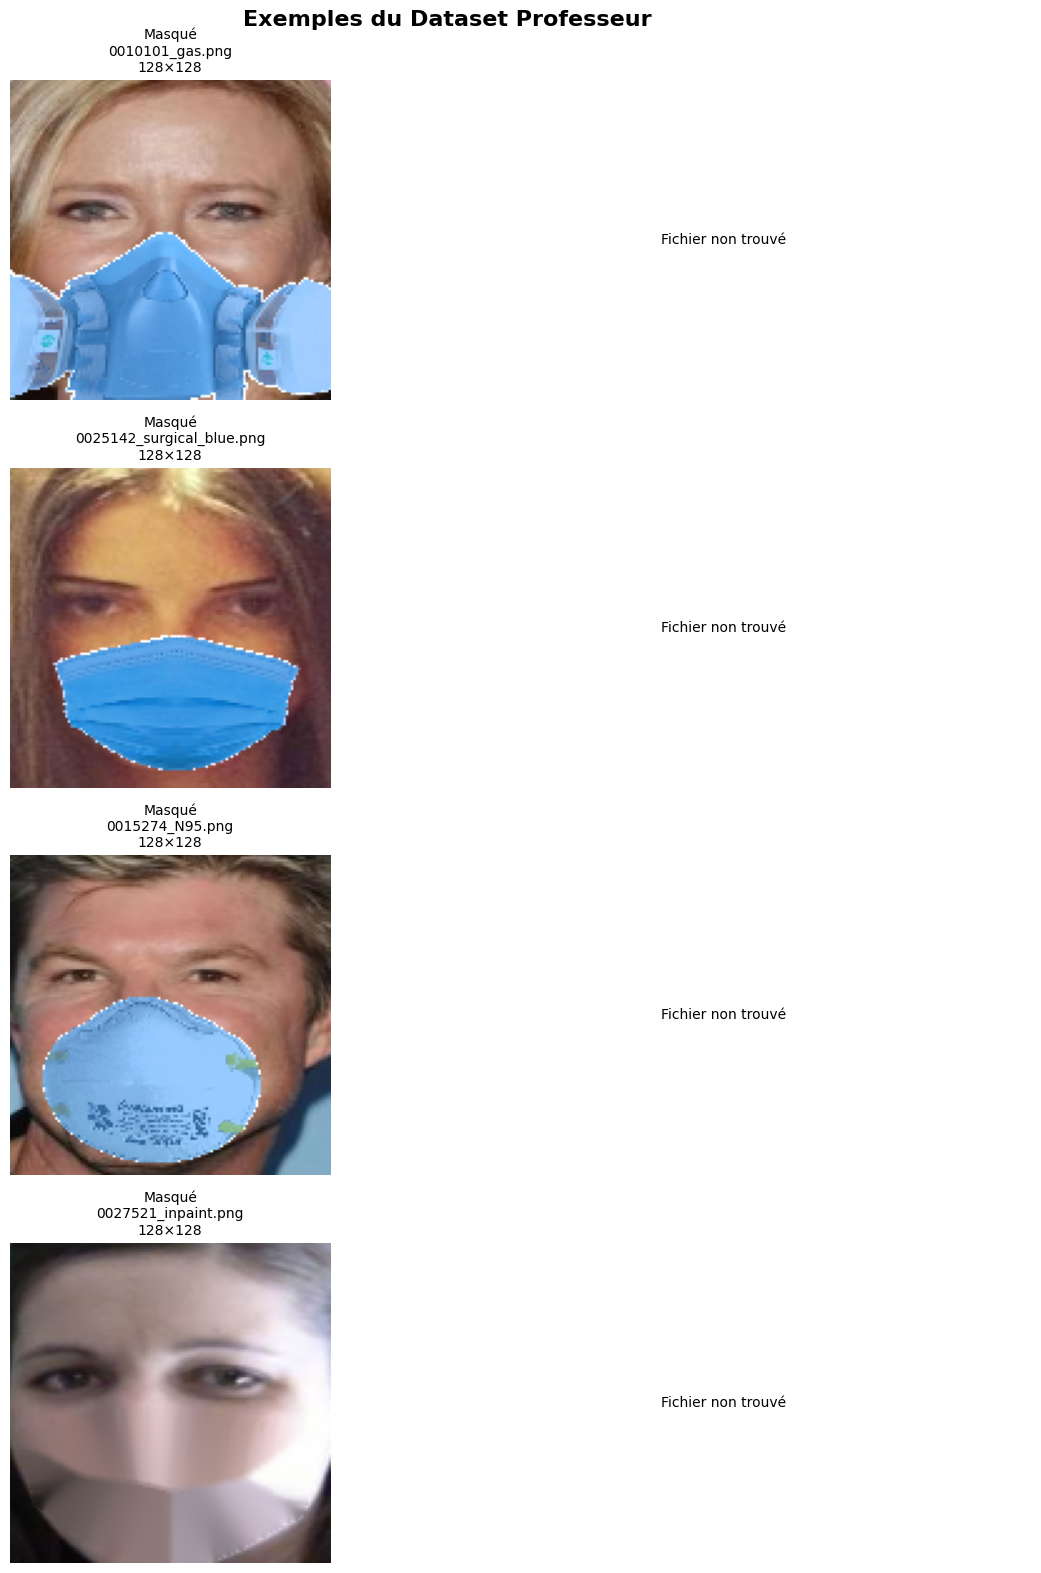

✅ Visualisation sauvegardée et affichée


📊 RECOMMANDATIONS

✅ Dataset analysé : 24678 paires détectées

⚠️  CORRECT mais peut être amélioré
   → Suffisant pour un premier entraînement
   → Possibilité d'ajouter CelebA si résultats < 27 PSNR

✅ DÉCISION : Commencer avec ce dataset
              Préparer CelebA en parallèle (optionnel)


📐 VÉRIFICATION DES DIMENSIONS REQUISES
------------------------------------------------------------
Dimensions actuelles :
  Masqué     : 128×128
  Non-masqué : 128×128

Dimensions requises :
  Input  : 32×32
  Target : 128×128

⚠️  RESIZE NÉCESSAIRE
   → Créer script de preprocessing
   → Voir 'preprocessing_script.py'

ANALYSE TERMINÉE

📝 Prochaines étapes :
1. ✅ Dataset analysé
2. Lire JDSR-GAN + Cheng EFBPGAN (2h)
3. Télécharger codes GitHub
4. Créer DataLoader PyTorch
5. Commencer l'implémentation !

💡 TIP KAGGLE :
   Activez GPU : Settings → Accelerator → GPU P100
   Cela sera nécessaire pour l'entraînement !


In [1]:
"""
SCRIPT D'ANALYSE DU DATASET - VERSION KAGGLE
À exécuter dans un notebook Kaggle
"""
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("="*60)
print("ANALYSE DU DATASET PROFESSEUR")
print("="*60)

# ============================================
# CONFIGURATION KAGGLE
# ============================================
DATASET_PATH = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images"

if not os.path.exists(DATASET_PATH):
    print(f"\n❌ Dataset introuvable : {DATASET_PATH}")
    print("\n💡 Vérifiez que vous avez bien ajouté le dataset dans votre notebook")
    print("   Settings → Add Data → Search 'masked celebahq cropped'")
    exit(1)

print(f"\n✅ Dataset trouvé : {DATASET_PATH}\n")

# ============================================
# 1. STRUCTURE DU DATASET
# ============================================
print("📁 STRUCTURE DU DATASET")
print("-" * 60)

def analyze_structure(path, level=0, max_level=2):
    """Analyse récursive de la structure"""
    if level > max_level:
        return
    
    try:
        items = sorted(os.listdir(path))
        for item in items[:20]:  # Afficher plus d'items
            item_path = os.path.join(path, item)
            indent = "  " * level
            
            if os.path.isdir(item_path):
                try:
                    num_files = len(os.listdir(item_path))
                    print(f"{indent}📁 {item}/ ({num_files} items)")
                    if level < max_level:
                        analyze_structure(item_path, level + 1, max_level)
                except:
                    print(f"{indent}📁 {item}/ (inaccessible)")
            else:
                size_mb = os.path.getsize(item_path) / (1024 * 1024)
                print(f"{indent}📄 {item} ({size_mb:.2f} MB)")
        
        if len(items) > 20:
            print(f"{indent}... et {len(items) - 20} autres items")
    except Exception as e:
        print(f"Erreur : {e}")

analyze_structure(DATASET_PATH)

# ============================================
# 2. TROUVER LES DOSSIERS IMAGES
# ============================================
print("\n\n🔍 RECHERCHE DES DOSSIERS D'IMAGES")
print("-" * 60)

def find_image_dirs(root_path):
    """Trouve tous les dossiers contenant des images"""
    image_dirs = {}
    
    for dirpath, dirnames, filenames in os.walk(root_path):
        # Compter les images dans ce dossier
        images = [f for f in filenames 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if images:
            rel_path = os.path.relpath(dirpath, root_path)
            image_dirs[rel_path] = len(images)
    
    return image_dirs

image_dirs = find_image_dirs(DATASET_PATH)

print("\nDossiers trouvés :")
for dir_name, count in sorted(image_dirs.items(), key=lambda x: x[1], reverse=True):
    print(f"  {dir_name:50s} : {count:6d} images")

# ============================================
# 3. IDENTIFIER MASQUÉ vs NON-MASQUÉ
# ============================================
print("\n\n🎭 IDENTIFICATION MASQUÉ / NON-MASQUÉ")
print("-" * 60)

masked_dir = None
unmasked_dir = None

# Chercher avec différents patterns possibles
for dir_name in image_dirs.keys():
    dir_lower = dir_name.lower()
    
    # Patterns pour masqué
    if any(keyword in dir_lower for keyword in ['mask', 'masked', 'with_mask', 'withmask']):
        if not any(kw in dir_lower for kw in ['unmask', 'unmasked', 'without', 'clean']):
            masked_dir = dir_name
            print(f"✅ Trouvé MASQUÉ : {dir_name}")
    
    # Patterns pour non-masqué  
    if any(keyword in dir_lower for keyword in ['unmask', 'unmasked', 'without', 'clean', 'original', 'no_mask', 'nomask']):
        unmasked_dir = dir_name
        print(f"✅ Trouvé NON-MASQUÉ : {dir_name}")

# Si pas trouvé automatiquement, essayer des chemins probables
if not masked_dir or not unmasked_dir:
    print("\n⚠️  Détection automatique échouée, test des chemins standards...")
    
    possible_paths = [
        ('facesDataset_masked', 'facesDataset'),
        ('masked', 'unmasked'),
        ('with_mask', 'without_mask'),
        ('.', '.')  # Parfois les images sont directement dans le dossier root
    ]
    
    for mask_path, unmask_path in possible_paths:
        test_masked = os.path.join(DATASET_PATH, mask_path) if mask_path != '.' else DATASET_PATH
        test_unmasked = os.path.join(DATASET_PATH, unmask_path) if unmask_path != '.' else DATASET_PATH
        
        if os.path.exists(test_masked) and os.path.exists(test_unmasked):
            masked_files = [f for f in os.listdir(test_masked) if f.endswith(('.png', '.jpg'))]
            unmasked_files = [f for f in os.listdir(test_unmasked) if f.endswith(('.png', '.jpg'))]
            
            if masked_files and unmasked_files:
                masked_dir = mask_path
                unmasked_dir = unmask_path
                print(f"✅ Détecté : {mask_path} / {unmask_path}")
                break

if masked_dir:
    print(f"\n✅ Dossier MASQUÉ     : {masked_dir}")
    print(f"   → {image_dirs.get(masked_dir, 0)} images")
else:
    print(f"\n❌ Dossier MASQUÉ non trouvé")

if unmasked_dir:
    print(f"\n✅ Dossier NON-MASQUÉ : {unmasked_dir}")
    print(f"   → {image_dirs.get(unmasked_dir, 0)} images")
else:
    print(f"\n❌ Dossier NON-MASQUÉ non trouvé")

if not masked_dir or not unmasked_dir:
    print("\n⚠️  ATTENTION : Vérifiez manuellement la structure")
    print("Listez les dossiers disponibles ci-dessus")

# ============================================
# 4. ANALYSE DES DIMENSIONS
# ============================================
print("\n\n📐 ANALYSE DES DIMENSIONS")
print("-" * 60)

def analyze_dimensions(dir_path, sample_size=100):
    """Analyse les dimensions d'un échantillon"""
    if not dir_path:
        return None
        
    full_path = os.path.join(DATASET_PATH, dir_path) if dir_path != '.' else DATASET_PATH
    
    if not os.path.exists(full_path):
        return None
    
    images = [f for f in os.listdir(full_path) 
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not images:
        return None
    
    # Échantillonner
    sample = np.random.choice(images, min(sample_size, len(images)), replace=False)
    
    dimensions = []
    for img_name in sample:
        try:
            img_path = os.path.join(full_path, img_name)
            with Image.open(img_path) as img:
                dimensions.append(img.size)  # (width, height)
        except Exception as e:
            continue
    
    return dimensions

dims_masked = None
dims_unmasked = None

if masked_dir:
    print(f"\nImages MASQUÉES :")
    dims_masked = analyze_dimensions(masked_dir)
    if dims_masked:
        dim_counts = Counter(dims_masked)
        for dim, count in dim_counts.most_common(5):
            percentage = (count / len(dims_masked)) * 100
            print(f"  {dim[0]}×{dim[1]} : {count} images ({percentage:.1f}%)")
    else:
        print("  ❌ Impossible d'analyser les dimensions")

if unmasked_dir:
    print(f"\nImages NON-MASQUÉES :")
    dims_unmasked = analyze_dimensions(unmasked_dir)
    if dims_unmasked:
        dim_counts = Counter(dims_unmasked)
        for dim, count in dim_counts.most_common(5):
            percentage = (count / len(dims_unmasked)) * 100
            print(f"  {dim[0]}×{dim[1]} : {count} images ({percentage:.1f}%)")
    else:
        print("  ❌ Impossible d'analyser les dimensions")

# ============================================
# 5. VÉRIFIER SI PAIRES
# ============================================
print("\n\n🔗 VÉRIFICATION DES PAIRES")
print("-" * 60)

masked_files = []
unmasked_files = []

if masked_dir and unmasked_dir:
    masked_path = os.path.join(DATASET_PATH, masked_dir) if masked_dir != '.' else DATASET_PATH
    unmasked_path = os.path.join(DATASET_PATH, unmasked_dir) if unmasked_dir != '.' else DATASET_PATH
    
    masked_files = sorted([f for f in os.listdir(masked_path) 
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    unmasked_files = sorted([f for f in os.listdir(unmasked_path) 
                            if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    
    print(f"\nNombre de fichiers masqués    : {len(masked_files)}")
    print(f"Nombre de fichiers non-masqués : {len(unmasked_files)}")
    
    # Comparer noms
    if len(masked_files) == len(unmasked_files):
        print("✅ Même nombre de fichiers")
        
        # Vérifier si noms correspondent
        if masked_files[:10] == unmasked_files[:10]:
            print("✅ Les noms de fichiers correspondent")
            print("\nExemples de paires :")
            for i in range(min(5, len(masked_files))):
                print(f"  {i+1}. {masked_files[i]}")
        else:
            print("⚠️  Les noms de fichiers NE correspondent PAS")
            print("\nMasqué (premiers 3)   :", masked_files[:3])
            print("Non-masqué (premiers 3):", unmasked_files[:3])
    else:
        print("⚠️  Nombre de fichiers DIFFÉRENT")
        diff = abs(len(masked_files) - len(unmasked_files))
        print(f"   Différence : {diff} fichiers")

# ============================================
# 6. VISUALISATION D'EXEMPLES  
# ============================================
print("\n\n📸 GÉNÉRATION DE VISUALISATIONS")
print("-" * 60)

if masked_dir and unmasked_dir and masked_files:
    try:
        masked_path = os.path.join(DATASET_PATH, masked_dir) if masked_dir != '.' else DATASET_PATH
        unmasked_path = os.path.join(DATASET_PATH, unmasked_dir) if unmasked_dir != '.' else DATASET_PATH
        
        # Prendre 4 exemples aléatoires
        sample_files = np.random.choice(masked_files, min(4, len(masked_files)), replace=False)
        
        fig, axes = plt.subplots(4, 2, figsize=(12, 16))
        fig.suptitle("Exemples du Dataset Professeur", fontsize=16, fontweight='bold')
        
        for i, filename in enumerate(sample_files):
            # Image masquée
            masked_img_path = os.path.join(masked_path, filename)
            try:
                masked_img = Image.open(masked_img_path)
                axes[i, 0].imshow(masked_img)
                axes[i, 0].set_title(f"Masqué\n{filename[:30]}\n{masked_img.size[0]}×{masked_img.size[1]}", 
                                    fontsize=10)
                axes[i, 0].axis('off')
            except Exception as e:
                axes[i, 0].text(0.5, 0.5, f"Erreur: {str(e)[:50]}", 
                              ha='center', va='center', fontsize=8)
                axes[i, 0].axis('off')
            
            # Image non-masquée
            unmasked_img_path = os.path.join(unmasked_path, filename)
            if os.path.exists(unmasked_img_path):
                try:
                    unmasked_img = Image.open(unmasked_img_path)
                    axes[i, 1].imshow(unmasked_img)
                    axes[i, 1].set_title(f"Non-masqué\n{filename[:30]}\n{unmasked_img.size[0]}×{unmasked_img.size[1]}", 
                                        fontsize=10)
                    axes[i, 1].axis('off')
                except Exception as e:
                    axes[i, 1].text(0.5, 0.5, f"Erreur: {str(e)[:50]}", 
                                  ha='center', va='center', fontsize=8)
                    axes[i, 1].axis('off')
            else:
                axes[i, 1].text(0.5, 0.5, "Fichier non trouvé", 
                              ha='center', va='center')
                axes[i, 1].axis('off')
        
        plt.tight_layout()
        plt.savefig("dataset_prof_examples.png", dpi=150, bbox_inches='tight')
        plt.show()  # Afficher dans Kaggle
        print("✅ Visualisation sauvegardée et affichée")
        
    except Exception as e:
        print(f"❌ Erreur lors de la visualisation : {e}")
else:
    print("⚠️  Impossible de créer la visualisation")
    print("   Vérifiez que les dossiers sont correctement identifiés")

# ============================================
# 7. RECOMMANDATIONS
# ============================================
print("\n\n" + "="*60)
print("📊 RECOMMANDATIONS")
print("="*60)

total_pairs = min(len(masked_files), len(unmasked_files)) if masked_files and unmasked_files else 0

print(f"\n✅ Dataset analysé : {total_pairs} paires détectées")

if total_pairs >= 25000:
    print("\n🎉 EXCELLENT ! Dataset très large")
    print("   → Suffisant pour entraînement complet")
    print("   → PAS besoin de combiner avec d'autres datasets")
    print("\n✅ DÉCISION : Utiliser ce dataset tel quel")
    
elif total_pairs >= 15000:
    print("\n⚠️  CORRECT mais peut être amélioré")
    print("   → Suffisant pour un premier entraînement")
    print("   → Possibilité d'ajouter CelebA si résultats < 27 PSNR")
    print("\n✅ DÉCISION : Commencer avec ce dataset")
    print("              Préparer CelebA en parallèle (optionnel)")
    
elif total_pairs >= 5000:
    print("\n⚠️  PETIT - Combinaison recommandée")
    print("   → Risque d'overfitting")
    print("   → Recommandé : Ajouter 15-20k images de CelebA")
    print("\n✅ DÉCISION : Combiner avec CelebA")
    print(f"              Objectif : {total_pairs} + 15000 = ~{total_pairs + 15000} paires")
    
else:
    print("\n❌ TRÈS PETIT ou INTROUVABLE")
    if total_pairs == 0:
        print("   → Vérifiez la structure du dataset")
        print("   → Assurez-vous d'avoir ajouté le bon dataset dans Kaggle")
    else:
        print("   → Impossible d'entraîner un GAN avec < 5000 images")
        print("   → DOIT combiner avec CelebA")

# ============================================
# 8. VÉRIFIER DIMENSIONS REQUISES
# ============================================
if dims_masked and dims_unmasked:
    most_common_masked = Counter(dims_masked).most_common(1)[0][0]
    most_common_unmasked = Counter(dims_unmasked).most_common(1)[0][0]
    
    print(f"\n\n📐 VÉRIFICATION DES DIMENSIONS REQUISES")
    print("-" * 60)
    print(f"Dimensions actuelles :")
    print(f"  Masqué     : {most_common_masked[0]}×{most_common_masked[1]}")
    print(f"  Non-masqué : {most_common_unmasked[0]}×{most_common_unmasked[1]}")
    
    print(f"\nDimensions requises :")
    print(f"  Input  : 32×32")
    print(f"  Target : 128×128")
    
    need_resize = (most_common_masked != (32, 32) or 
                   most_common_unmasked != (128, 128))
    
    if need_resize:
        print(f"\n⚠️  RESIZE NÉCESSAIRE")
        print(f"   → Créer script de preprocessing")
        print(f"   → Voir 'preprocessing_script.py'")
    else:
        print(f"\n✅ DIMENSIONS CORRECTES")
        print(f"   → Dataset prêt à l'emploi !")

print("\n" + "="*60)
print("ANALYSE TERMINÉE")
print("="*60)

if total_pairs > 0:
    print("\n📝 Prochaines étapes :")
    print("1. ✅ Dataset analysé")
    print("2. Lire JDSR-GAN + Cheng EFBPGAN (2h)")
    print("3. Télécharger codes GitHub")
    print("4. Créer DataLoader PyTorch")
    print("5. Commencer l'implémentation !")
else:
    print("\n⚠️  Problème détecté :")
    print("1. Vérifiez que le dataset est bien ajouté dans Kaggle")
    print("2. Regardez la structure affichée ci-dessus")
    print("3. Ajustez les chemins si nécessaire")
    
print("\n💡 TIP KAGGLE :")
print("   Activez GPU : Settings → Accelerator → GPU P100")
print("   Cela sera nécessaire pour l'entraînement !")


**PREPROCESSING DATASET - Créer les bonnes dimensions32×32 masqué → 128×128 non-masqué**

In [2]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil

print("="*60)
print("PREPROCESSING DATASET")
print("="*60)

# ============================================
# CONFIGURATION
# ============================================
INPUT_MASKED = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images/facesDataset_masked"
INPUT_UNMASKED = "/kaggle/input/datasets/yyazidd/masked-celebahq-cropped-images/facesDataset"

OUTPUT_DIR = "/kaggle/working/dataset_processed"

# Création dossiers
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "input_32"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "target_128"), exist_ok=True)

print(f"\n✅ Dossiers créés dans : {OUTPUT_DIR}\n")

# ============================================
# CRÉER LES PAIRES
# ============================================
print("🔍 Identification des paires...")

masked_files = sorted([f for f in os.listdir(INPUT_MASKED) if f.endswith('.png')])
pairs = []

for masked_file in masked_files:
    num_str = masked_file[:7]
    unmasked_file = f"{num_str}.png"
    unmasked_path = os.path.join(INPUT_UNMASKED, unmasked_file)

    if os.path.exists(unmasked_path):
        pairs.append((masked_file, unmasked_file))

print(f"✅ {len(pairs)} paires trouvées\n")

# ============================================
# SPLIT TRAIN/VAL/TEST
# ============================================
np.random.seed(42)
np.random.shuffle(pairs)

n_train = int(len(pairs) * 0.8)
n_val = int(len(pairs) * 0.1)

train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

print(f"📊 Split :")
print(f"  Train : {len(train_pairs)}")
print(f"  Val   : {len(val_pairs)}")
print(f"  Test  : {len(test_pairs)}\n")

# ============================================
# FONCTION DE TRAITEMENT
# ============================================
def process_pair(masked_file, unmasked_file, split_name, idx):

    masked_path = os.path.join(INPUT_MASKED, masked_file)
    unmasked_path = os.path.join(INPUT_UNMASKED, unmasked_file)

    masked_img = cv2.imread(masked_path)
    unmasked_img = cv2.imread(unmasked_path)

    if masked_img is None:
        print(f"❌ Erreur lecture : {masked_path}")
        return False

    if unmasked_img is None:
        print(f"❌ Erreur lecture : {unmasked_path}")
        return False

    # Resize INPUT 32x32
    masked_32 = cv2.resize(masked_img, (32, 32), interpolation=cv2.INTER_CUBIC)

    # TARGET reste 128x128
    unmasked_128 = unmasked_img

    input_path = os.path.join(OUTPUT_DIR, split_name, "input_32", f"{idx:06d}.png")
    target_path = os.path.join(OUTPUT_DIR, split_name, "target_128", f"{idx:06d}.png")

    # Vérifier que l'écriture fonctionne
    ok1 = cv2.imwrite(input_path, masked_32)
    ok2 = cv2.imwrite(target_path, unmasked_128)

    if not ok1 or not ok2:
        print(f"❌ Erreur sauvegarde : {idx}")
        return False

    return True

# ============================================
# TRAITEMENT SPLITS
# ============================================
def process_split(pairs, split_name):

    print(f"\n🔄 Processing {split_name.upper()}...")
    success = 0

    for idx, (masked_file, unmasked_file) in enumerate(tqdm(pairs)):
        if process_pair(masked_file, unmasked_file, split_name, idx):
            success += 1

    print(f"✅ {split_name}: {success}/{len(pairs)} sauvegardées")
    return success


train_success = process_split(train_pairs, "train")
val_success = process_split(val_pairs, "val")
test_success = process_split(test_pairs, "test")

# ============================================
# RÉSUMÉ
# ============================================
print("\n" + "="*60)
print("✅ PREPROCESSING TERMINÉ")
print("="*60)

total = train_success + val_success + test_success
print(f"\n📊 TOTAL sauvegardé : {total} images")

# ============================================
# VÉRIFICATION
# ============================================
if train_success > 0:
    example_input = cv2.imread(os.path.join(OUTPUT_DIR, "train/input_32/000000.png"))
    example_target = cv2.imread(os.path.join(OUTPUT_DIR, "train/target_128/000000.png"))

    print("\n🔎 Vérification dimensions :")
    print("Input  :", example_input.shape)
    print("Target :", example_target.shape)

# ============================================
# ZIP FINAL
# ============================================
print("\n📦 Compression en cours...")

zip_path = shutil.make_archive(
    os.path.join("/kaggle/working", "dataset_processed"),
    'zip',
    OUTPUT_DIR
)

print(f"✅ ZIP créé : {zip_path}")
print("Télécharge-le depuis l’onglet OUTPUT de Kaggle.")

PREPROCESSING DATASET

✅ Dossiers créés dans : /kaggle/working/dataset_processed

🔍 Identification des paires...
✅ 24678 paires trouvées

📊 Split :
  Train : 19742
  Val   : 2467
  Test  : 2469


🔄 Processing TRAIN...


100%|██████████| 19742/19742 [03:33<00:00, 92.35it/s] 


✅ train: 19742/19742 sauvegardées

🔄 Processing VAL...


100%|██████████| 2467/2467 [00:26<00:00, 93.21it/s]


✅ val: 2467/2467 sauvegardées

🔄 Processing TEST...


100%|██████████| 2469/2469 [00:26<00:00, 93.96it/s]


✅ test: 2469/2469 sauvegardées

✅ PREPROCESSING TERMINÉ

📊 TOTAL sauvegardé : 24678 images

🔎 Vérification dimensions :
Input  : (32, 32, 3)
Target : (128, 128, 3)

📦 Compression en cours...
✅ ZIP créé : /kaggle/working/dataset_processed.zip
Télécharge-le depuis l’onglet OUTPUT de Kaggle.


**Vérifications et installations**

SETUP ENVIRONNEMENT KAGGLE

🔍 Vérification GPU...
PyTorch version : 2.9.0+cu126
CUDA disponible : True
CUDA version : 12.6
GPU name : Tesla T4
GPU memory : 15.64 GB
✅ GPU activé !

📦 Installation des packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.1 MB/s eta 0:00:00
✅ Packages installés

📚 Test des imports...
✅ Tous les imports fonctionnent

📁 Vérification du dataset...
Train inputs  : 19742 images
Train targets : 19742 images
✅ Dataset prêt !

🖼️  Test chargement d'une image...
Input shape  : (32, 32, 3)
Target shape : (128, 128, 3)


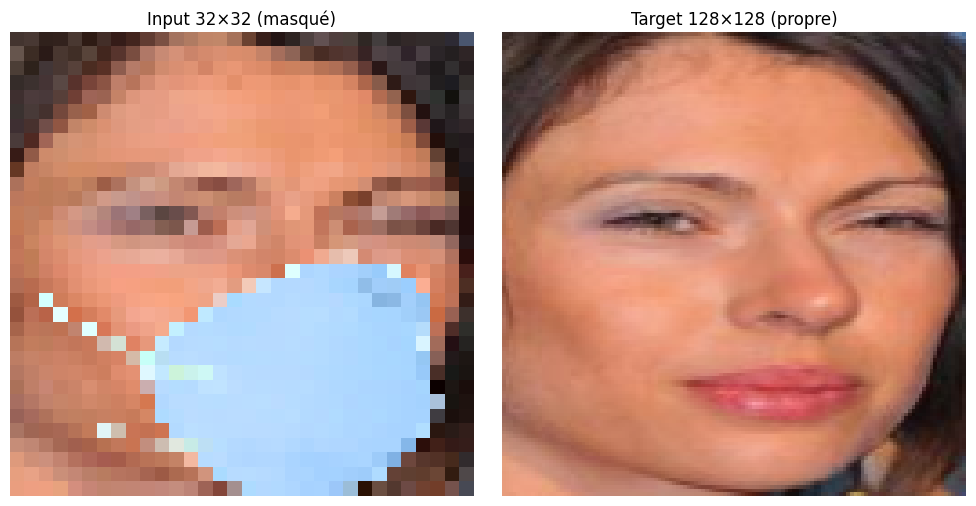


✅ Test réussi !

📊 RÉSUMÉ SETUP
✅ GPU : Activé
✅ PyTorch : 2.9.0+cu126
✅ Dataset : 19742 paires train
✅ Packages : opencv, lpips, timm, torchmetrics

🎯 Prêt pour l'implémentation !


In [3]:
"""
SETUP ENVIRONNEMENT - Vérifications et installations
"""

print("="*60)
print("SETUP ENVIRONNEMENT KAGGLE")
print("="*60)

# ============================================
# 1. VÉRIFIER GPU
# ============================================
print("\n🔍 Vérification GPU...")
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version : {torch.version.cuda}")
    print(f"GPU name : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print("✅ GPU activé !")
else:
    print("❌ GPU non disponible")
    print("→ Aller dans Settings → Accelerator → GPU P100")

# ============================================
# 2. INSTALLER PACKAGES
# ============================================
print("\n📦 Installation des packages...")

!pip install -q opencv-python-headless
!pip install -q lpips  # Pour métrique perceptuelle
!pip install -q timm   # Pour certains backbones
!pip install -q torchmetrics  # Pour PSNR, SSIM

print("✅ Packages installés")

# ============================================
# 3. IMPORTS DE BASE
# ============================================
print("\n📚 Test des imports...")

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

import os
import glob
from pathlib import Path

print("✅ Tous les imports fonctionnent")

# ============================================
# 4. VÉRIFIER DATASET
# ============================================
print("\n📁 Vérification du dataset...")

DATASET_PATH = "/kaggle/working/dataset_processed"

train_input_path = f"{DATASET_PATH}/train/input_32"
train_target_path = f"{DATASET_PATH}/train/target_128"

num_train_input = len(glob.glob(f"{train_input_path}/*.png"))
num_train_target = len(glob.glob(f"{train_target_path}/*.png"))

print(f"Train inputs  : {num_train_input} images")
print(f"Train targets : {num_train_target} images")

if num_train_input == num_train_target and num_train_input > 0:
    print("✅ Dataset prêt !")
else:
    print("❌ Problème avec le dataset")

# ============================================
# 5. TEST CHARGEMENT IMAGE
# ============================================
print("\n🖼️  Test chargement d'une image...")

# Charger une paire
input_img = cv2.imread(f"{train_input_path}/000000.png")
target_img = cv2.imread(f"{train_target_path}/000000.png")

print(f"Input shape  : {input_img.shape}")
print(f"Target shape : {target_img.shape}")

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Input 32×32 (masqué)")
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Target 128×128 (propre)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Test réussi !")

# ============================================
# 6. RÉSUMÉ
# ============================================
print("\n" + "="*60)
print("📊 RÉSUMÉ SETUP")
print("="*60)
print(f"✅ GPU : {'Activé' if torch.cuda.is_available() else 'Non activé'}")
print(f"✅ PyTorch : {torch.__version__}")
print(f"✅ Dataset : {num_train_input} paires train")
print(f"✅ Packages : opencv, lpips, timm, torchmetrics")
print("\n🎯 Prêt pour l'implémentation !")



**verification  que GPU est activé**

In [4]:
import torch

print("="*60)
print("VÉRIFICATION GPU")
print("="*60)

if torch.cuda.is_available():
    print("✅ GPU ACTIVÉ")
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"Mémoire : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ GPU NON ACTIVÉ")
    print("→ Settings → Accelerator → GPU P100")

VÉRIFICATION GPU
✅ GPU ACTIVÉ
GPU : Tesla T4
Mémoire : 15.64 GB


**DATALOADER PYTORCH - MEFSR-GANPour charger les paires 32×32 → 128×128**

In [7]:
%%writefile /kaggle/working/create_dataloader.py
"""
DATALOADER PYTORCH - MEFSR-GAN avec data augmentation
"""

import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
from pathlib import Path
import glob
import random

class FaceSRDataset(Dataset):
    """
    Dataset avec option d'augmentation pour l'entraînement.
    """
    def __init__(self, data_root, train=True):
        self.data_root = Path(data_root)
        self.train = train
        self.input_files = sorted(glob.glob(str(self.data_root / "input_32" / "*.png")))
        self.target_files = sorted(glob.glob(str(self.data_root / "target_128" / "*.png")))
        assert len(self.input_files) == len(self.target_files), \
            f"Mismatch: {len(self.input_files)} inputs vs {len(self.target_files)} targets"

    def __len__(self):
        return len(self.input_files)

    def __getitem__(self, idx):
        # Chargement des images
        input_img = cv2.imread(self.input_files[idx])
        target_img = cv2.imread(self.target_files[idx])

        # BGR → RGB
        input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        target_img = cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB)

        # Normalisation [0, 255] → [0, 1]
        input_img = input_img.astype(np.float32) / 255.0
        target_img = target_img.astype(np.float32) / 255.0

        # Conversion en tenseurs (C, H, W)
        input_tensor = torch.from_numpy(input_img).permute(2, 0, 1)
        target_tensor = torch.from_numpy(target_img).permute(2, 0, 1)

        # Data augmentation (uniquement pour l'entraînement)
        if self.train:
            # Random horizontal flip (même pour les deux images)
            if random.random() > 0.5:
                input_tensor = torch.flip(input_tensor, dims=[2])
                target_tensor = torch.flip(target_tensor, dims=[2])

            # Vous pouvez ajouter d'autres augmentations ici si vous le souhaitez
            # (attention à les appliquer de manière cohérente aux deux images)

        return input_tensor, target_tensor

def create_dataloaders(dataset_root, batch_size=16, num_workers=2):
    """
    Crée les DataLoaders train/val/test avec augmentation pour le train.
    """
    train_root = Path(dataset_root) / "train"
    val_root = Path(dataset_root) / "val"
    test_root = Path(dataset_root) / "test"

    train_dataset = FaceSRDataset(train_root, train=True)
    val_dataset = FaceSRDataset(val_root, train=False)
    test_dataset = FaceSRDataset(test_root, train=False)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    return train_loader, val_loader, test_loader

Overwriting /kaggle/working/create_dataloader.py


1. **MODULE 1 : MASK REMOVAL**

In [8]:
%%writefile /kaggle/working/module1_mask_removal.py
"""
MODULE 1 : MASK REMOVAL
Inspiré de JDSR-GAN (2023)

Objectif : Enlever le masque facial et reconstruire les zones cachées
Input : [B, 3, 32, 32] (visage masqué LR)
Output : [B, 64, 32, 32] (features débruitées)
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    """
    Bloc résiduel de base avec skip connection
    """
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
    
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += residual  # Skip connection
        out = self.relu(out)
        return out


class MaskRemovalModule(nn.Module):
    """
    Module de débruitage pour enlever le masque facial
    
    Architecture progressive :
    - Version 1.0 : Architecture simple mais fonctionnelle
    - Version 2.0 : Ajouter plus de résidual blocks si besoin
    
    Args:
        in_channels (int) : Canaux d'entrée (3 pour RGB)
        out_channels (int) : Canaux de sortie (64 features)
        num_residual_blocks (int) : Nombre de blocs résiduels (défaut 4)
    """
    
    def __init__(self, in_channels=3, out_channels=64, num_residual_blocks=4):
        super(MaskRemovalModule, self).__init__()
        
        # Encoder : Extraire features
        self.initial_conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        
        # Résidual blocks : Traiter le masque comme du bruit
        self.residual_blocks = nn.ModuleList([
            ResidualBlock(64) for _ in range(num_residual_blocks)
        ])
        
        # Decoder : Reconstruire les features propres
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x : [B, 3, 32, 32] image masquée
        
        Returns:
            features : [B, 64, 32, 32] features débruitées
        """
        # Encoder
        features = self.initial_conv(x)  # [B, 64, 32, 32]
        
        # Résidual processing (débruitage)
        for res_block in self.residual_blocks:
            features = res_block(features)  # [B, 64, 32, 32]
        
        # Decoder
        features = self.decoder(features)  # [B, 64, 32, 32]
        
        return features


# ============================================
# TEST DU MODULE
# ============================================
if __name__ == "__main__":
    print("="*60)
    print("TEST MODULE 1 : MASK REMOVAL")
    print("="*60)
    
    # Créer le module
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice : {device}")
    
    model = MaskRemovalModule(
        in_channels=3,
        out_channels=64,
        num_residual_blocks=4
    ).to(device)
    
    # Compter les paramètres
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Nombre de paramètres : {num_params:,}")
    
    # Test avec un batch
    batch_size = 4
    x = torch.randn(batch_size, 3, 32, 32).to(device)
    
    print(f"\nInput shape : {x.shape}")
    
    # Forward pass
    with torch.no_grad():
        features = model(x)
    
    print(f"Output shape : {features.shape}")
    
    # Vérifier dimensions
    assert features.shape == (batch_size, 64, 32, 32), "Dimensions incorrectes !"
    
    print("\n✅ Module 1 fonctionne correctement !")
    
    # Vérifier mémoire GPU
    if torch.cuda.is_available():
        memory_used = torch.cuda.memory_allocated(device) / 1e9
        print(f"GPU memory used : {memory_used:.2f} GB")
    
    print("="*60)

Writing /kaggle/working/module1_mask_removal.py


**2. MODULE 2 : EDGE FUSION**

In [9]:
%%writefile /kaggle/working/module2_edge_fusion.py
"""
MODULE 2 : EDGE FUSION
Inspiré de Cheng EFBPGAN (2024)

VERSION 1.0 : Simple concat features + edges
VERSION 2.0 : Ajouter Attention Fusion (si temps)

Input : [B, 64, 32, 32] features + [B, 1, 32, 32] edges
Output : [B, 64, 32, 32] features enrichies
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import cv2
import numpy as np


# ============================================
# EXTRACTION EDGES (CANNY)
# ============================================
def extract_edges_canny(images, low_threshold=50, high_threshold=150):
    """
    Extrait les contours via l'algorithme de Canny
    
    Args:
        images : [B, 3, H, W] tensor (valeurs [0, 1])
        low_threshold : Seuil bas Canny (défaut 50)
        high_threshold : Seuil haut Canny (défaut 150)
    
    Returns:
        edges : [B, 1, H, W] tensor (valeurs [0, 1])
    """
    batch_size, _, H, W = images.shape
    device = images.device
    
    edges_batch = []
    
    for i in range(batch_size):
        # Convertir en numpy (CPU)
        img = images[i].cpu().permute(1, 2, 0).numpy()  # [H, W, 3]
        img = (img * 255).astype(np.uint8)
        
        # Convertir en grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        
        # Appliquer Canny
        edges = cv2.Canny(gray, low_threshold, high_threshold)
        
        # Normaliser [0, 255] → [0, 1]
        edges = edges.astype(np.float32) / 255.0
        
        edges_batch.append(edges)
    
    # Convertir en tensor
    edges_batch = np.stack(edges_batch, axis=0)  # [B, H, W]
    edges_tensor = torch.from_numpy(edges_batch).unsqueeze(1)  # [B, 1, H, W]
    
    return edges_tensor.to(device)


# ============================================
# VERSION 1.0 : FUSION SIMPLE (CONCAT)
# ============================================
class EdgeFusionSimple(nn.Module):
    """
    Version 1.0 : Fusion simple par concatenation
    
    Plus rapide à implémenter et débugger
    À utiliser en premier pour avoir quelque chose qui marche
    """
    
    def __init__(self, feature_channels=64):
        super(EdgeFusionSimple, self).__init__()
        
        # Fusion : Features (64) + Edges (1) = 65 channels
        self.fusion = nn.Sequential(
            nn.Conv2d(feature_channels + 1, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(feature_channels, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, features, edges):
        """
        Args:
            features : [B, 64, 32, 32] features du Module 1
            edges : [B, 1, 32, 32] edges extraits par Canny
        
        Returns:
            fused : [B, 64, 32, 32] features enrichies
        """
        # Concat
        combined = torch.cat([features, edges], dim=1)  # [B, 65, 32, 32]
        
        # Fusion
        fused = self.fusion(combined)  # [B, 64, 32, 32]
        
        return fused


# ============================================
# VERSION 2.0 : ATTENTION FUSION (BONUS)
# ============================================
class ChannelAttention(nn.Module):
    """
    Channel Attention Module
    Détermine quels canaux sont importants
    """
    def __init__(self, channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)


class SpatialAttention(nn.Module):
    """
    Spatial Attention Module
    Détermine quelles zones spatiales sont importantes
    """
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)
        return self.sigmoid(x)


class EdgeFusionAttention(nn.Module):
    """
    Version 2.0 : Fusion avec Attention (Channel + Spatial)
    
    À implémenter APRÈS que la version simple marche
    """
    
    def __init__(self, feature_channels=64):
        super(EdgeFusionAttention, self).__init__()
        
        # Attention pour features
        self.channel_attn = ChannelAttention(feature_channels)
        self.spatial_attn = SpatialAttention()
        
        # Fusion finale
        self.fusion = nn.Sequential(
            nn.Conv2d(feature_channels + 1, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(feature_channels, feature_channels, 3, padding=1),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, features, edges):
        """
        Args:
            features : [B, 64, 32, 32] features du Module 1
            edges : [B, 1, 32, 32] edges extraits par Canny
        
        Returns:
            fused : [B, 64, 32, 32] features enrichies avec attention
        """
        # Channel Attention sur features
        ca_weight = self.channel_attn(features)  # [B, 64, 1, 1]
        features_ca = features * ca_weight  # [B, 64, 32, 32]
        
        # Spatial Attention sur edges (guider où regarder)
        sa_weight = self.spatial_attn(edges)  # [B, 1, 32, 32]
        features_sa = features_ca * sa_weight  # [B, 64, 32, 32]
        
        # Concat avec edges
        combined = torch.cat([features_sa, edges], dim=1)  # [B, 65, 32, 32]
        
        # Fusion
        fused = self.fusion(combined)  # [B, 64, 32, 32]
        
        return fused


# ============================================
# TEST DU MODULE
# ============================================
if __name__ == "__main__":
    print("="*60)
    print("TEST MODULE 2 : EDGE FUSION")
    print("="*60)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice : {device}")
    
    # Test extraction edges
    print("\n1. Test Canny Edge Extraction...")
    images = torch.rand(2, 3, 32, 32).to(device)
    edges = extract_edges_canny(images)
    print(f"   Images shape : {images.shape}")
    print(f"   Edges shape : {edges.shape}")
    print(f"   Edges range : [{edges.min():.3f}, {edges.max():.3f}]")
    
    # Test Version 1.0 (Simple)
    print("\n2. Test EdgeFusionSimple (v1.0)...")
    model_v1 = EdgeFusionSimple(feature_channels=64).to(device)
    features = torch.randn(2, 64, 32, 32).to(device)
    fused_v1 = model_v1(features, edges)
    print(f"   Input features : {features.shape}")
    print(f"   Output fused : {fused_v1.shape}")
    
    num_params_v1 = sum(p.numel() for p in model_v1.parameters())
    print(f"   Paramètres : {num_params_v1:,}")
    
    # Test Version 2.0 (Attention)
    print("\n3. Test EdgeFusionAttention (v2.0)...")
    model_v2 = EdgeFusionAttention(feature_channels=64).to(device)
    fused_v2 = model_v2(features, edges)
    print(f"   Output fused : {fused_v2.shape}")
    
    num_params_v2 = sum(p.numel() for p in model_v2.parameters())
    print(f"   Paramètres : {num_params_v2:,}")
    
    print("\n✅ Module 2 fonctionne correctement !")
    print("="*60)

Writing /kaggle/working/module2_edge_fusion.py


3. **MODULE 3 : SR NETWORK**

In [10]:
%%writefile /kaggle/working/module3_sr_network.py
"""
MODULE 3 : SR NETWORK
Super-Résolution : 32×32 → 128×128 (facteur ×4)

VERSION 1.0 : ResNet simple avec upsampling
VERSION 2.0 : RRDB blocks (ESRGAN) si temps
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================
# VERSION 1.0 : SR NETWORK SIMPLE (RESNET)
# ============================================
class ResidualBlockSR(nn.Module):
    """Bloc résiduel pour SR"""
    def __init__(self, channels):
        super(ResidualBlockSR, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.prelu = nn.PReLU()
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)
    
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        return out + residual


class UpsampleBlock(nn.Module):
    """
    Upsampling block (×2)
    Utilise PixelShuffle pour upsampler proprement
    """
    def __init__(self, in_channels, scale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, in_channels * (scale_factor ** 2), 3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)
        self.prelu = nn.PReLU()
    
    def forward(self, x):
        x = self.conv(x)
        x = self.pixel_shuffle(x)
        x = self.prelu(x)
        return x


class SRNetworkSimple(nn.Module):
    """
    Version 1.0 : SR Network simple mais efficace
    
    Architecture :
    - Features → Résidual blocks → Upsampling ×4 → RGB
    
    Args:
        in_channels (int) : Canaux d'entrée (64 features)
        out_channels (int) : Canaux de sortie (3 RGB)
        num_residual_blocks (int) : Nombre de blocs résiduels
    """
    
    def __init__(self, in_channels=64, out_channels=3, num_residual_blocks=8):
        super(SRNetworkSimple, self).__init__()
        
        # Initial conv
        self.conv_input = nn.Conv2d(in_channels, 64, 3, padding=1)
        self.prelu_input = nn.PReLU()
        
        # Résidual blocks
        self.residual_blocks = nn.ModuleList([
            ResidualBlockSR(64) for _ in range(num_residual_blocks)
        ])
        
        # Conv après résidual
        self.conv_mid = nn.Conv2d(64, 64, 3, padding=1)
        self.bn_mid = nn.BatchNorm2d(64)
        
        # Upsampling ×4 (2 blocs ×2)
        self.upsample1 = UpsampleBlock(64, scale_factor=2)  # 32 → 64
        self.upsample2 = UpsampleBlock(64, scale_factor=2)  # 64 → 128
        
        # Conv finale vers RGB
        self.conv_output = nn.Conv2d(64, out_channels, 3, padding=1)
    
    def forward(self, x):
        """
        Args:
            x : [B, 64, 32, 32] features enrichies
        
        Returns:
            out : [B, 3, 128, 128] image HR
        """
        # Initial
        out = self.conv_input(x)
        out = self.prelu_input(out)
        residual = out
        
        # Résidual blocks
        for block in self.residual_blocks:
            out = block(out)
        
        # Mid
        out = self.conv_mid(out)
        out = self.bn_mid(out)
        out = out + residual  # Long skip connection
        
        # Upsampling ×4
        out = self.upsample1(out)  # [B, 64, 64, 64]
        out = self.upsample2(out)  # [B, 64, 128, 128]
        
        # Output RGB
        out = self.conv_output(out)  # [B, 3, 128, 128]
        
        return out


# ============================================
# VERSION 2.0 : RRDB (ESRGAN) - BONUS
# ============================================
class DenseBlock(nn.Module):
    """Dense block pour RRDB"""
    def __init__(self, channels, growth_channels=32):
        super(DenseBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, growth_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(channels + growth_channels, growth_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(channels + 2*growth_channels, growth_channels, 3, padding=1)
        self.conv4 = nn.Conv2d(channels + 3*growth_channels, growth_channels, 3, padding=1)
        self.conv5 = nn.Conv2d(channels + 4*growth_channels, channels, 3, padding=1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.beta = 0.2  # Résidual scaling
    
    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat([x, x1], dim=1)))
        x3 = self.lrelu(self.conv3(torch.cat([x, x1, x2], dim=1)))
        x4 = self.lrelu(self.conv4(torch.cat([x, x1, x2, x3], dim=1)))
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], dim=1))
        return x5 * self.beta + x


class RRDB(nn.Module):
    """Residual in Residual Dense Block"""
    def __init__(self, channels, growth_channels=32):
        super(RRDB, self).__init__()
        self.dense1 = DenseBlock(channels, growth_channels)
        self.dense2 = DenseBlock(channels, growth_channels)
        self.dense3 = DenseBlock(channels, growth_channels)
        self.beta = 0.2
    
    def forward(self, x):
        out = self.dense1(x)
        out = self.dense2(out)
        out = self.dense3(out)
        return out * self.beta + x


class SRNetworkESRGAN(nn.Module):
    """
    Version 2.0 : SR Network avec RRDB (ESRGAN)
    
    À implémenter APRÈS que la version simple marche
    Plus puissant mais aussi plus complexe
    """
    
    def __init__(self, in_channels=64, out_channels=3, num_rrdb_blocks=16):
        super(SRNetworkESRGAN, self).__init__()
        
        # Initial
        self.conv_first = nn.Conv2d(in_channels, 64, 3, padding=1)
        
        # RRDB blocks
        self.rrdb_blocks = nn.ModuleList([
            RRDB(64, growth_channels=32) for _ in range(num_rrdb_blocks)
        ])
        
        # Conv après RRDB
        self.conv_body = nn.Conv2d(64, 64, 3, padding=1)
        
        # Upsampling
        self.upsample1 = UpsampleBlock(64, scale_factor=2)
        self.upsample2 = UpsampleBlock(64, scale_factor=2)
        
        # Output
        self.conv_hr = nn.Conv2d(64, 64, 3, padding=1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)
        self.conv_last = nn.Conv2d(64, out_channels, 3, padding=1)
    
    def forward(self, x):
        """
        Args:
            x : [B, 64, 32, 32]
        Returns:
            out : [B, 3, 128, 128]
        """
        feat = self.conv_first(x)
        trunk = feat
        
        for block in self.rrdb_blocks:
            trunk = block(trunk)
        
        trunk = self.conv_body(trunk)
        feat = feat + trunk  # Long skip
        
        feat = self.upsample1(feat)
        feat = self.upsample2(feat)
        
        out = self.conv_hr(feat)
        out = self.lrelu(out)
        out = self.conv_last(out)
        
        return out


# ============================================
# TEST DU MODULE
# ============================================
if __name__ == "__main__":
    print("="*60)
    print("TEST MODULE 3 : SR NETWORK")
    print("="*60)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice : {device}")
    
    # Test Version 1.0 (Simple)
    print("\n1. Test SRNetworkSimple (v1.0)...")
    model_v1 = SRNetworkSimple(
        in_channels=64,
        out_channels=3,
        num_residual_blocks=8
    ).to(device)
    
    x = torch.randn(2, 64, 32, 32).to(device)
    out_v1 = model_v1(x)
    
    print(f"   Input : {x.shape}")
    print(f"   Output : {out_v1.shape}")
    
    num_params_v1 = sum(p.numel() for p in model_v1.parameters())
    print(f"   Paramètres : {num_params_v1:,}")
    
    assert out_v1.shape == (2, 3, 128, 128), "Dimensions incorrectes !"
    
    # Test Version 2.0 (ESRGAN)
    print("\n2. Test SRNetworkESRGAN (v2.0)...")
    model_v2 = SRNetworkESRGAN(
        in_channels=64,
        out_channels=3,
        num_rrdb_blocks=8  # Moins que ESRGAN original (23) pour rapidité
    ).to(device)
    
    out_v2 = model_v2(x)
    
    print(f"   Output : {out_v2.shape}")
    
    num_params_v2 = sum(p.numel() for p in model_v2.parameters())
    print(f"   Paramètres : {num_params_v2:,}")
    
    print("\n✅ Module 3 fonctionne correctement !")
    
    if torch.cuda.is_available():
        memory = torch.cuda.memory_allocated(device) / 1e9
        print(f"\nGPU memory : {memory:.2f} GB")
    
    print("="*60)

Writing /kaggle/working/module3_sr_network.py


**4. MEFSR-GAN VERSION**

In [11]:
%%writefile /kaggle/working/mefsr_gan_v1.py

import torch
import torch.nn as nn
import torch.nn.functional as F

# Import des modules
import sys
sys.path.append('/kaggle/working/')

from module1_mask_removal import MaskRemovalModule
from module2_edge_fusion import EdgeFusionSimple, extract_edges_canny
from module3_sr_network import SRNetworkSimple


class MEFSR_GAN_v1(nn.Module):
    """
    MEFSR-GAN Version 1.0
    
    Architecture PROGRESSIVE :
    - Simple mais fonctionnelle
    - Facile à débugger
    - Résultats garantis
    
    Objectif PSNR : 26-27 dB
    Temps implémentation : 4 semaines
    """
    
    def __init__(self):
        super(MEFSR_GAN_v1, self).__init__()
        
        # Module 1 : Mask Removal
        self.mask_removal = MaskRemovalModule(
            in_channels=3,
            out_channels=64,
            num_residual_blocks=4
        )
        
        # Module 2 : Edge Fusion (Simple)
        self.edge_fusion = EdgeFusionSimple(
            feature_channels=64
        )
        
        # Module 3 : SR Network (Simple)
        self.sr_network = SRNetworkSimple(
            in_channels=64,
            out_channels=3,
            num_residual_blocks=8
        )
    
    def forward(self, x):
        """
        Forward pass complet
        
        Args:
            x : [B, 3, 32, 32] visage masqué LR
        
        Returns:
            output : [B, 3, 128, 128] visage propre HR
        """
        # Module 1 : Enlever masque
        features = self.mask_removal(x)  # [B, 64, 32, 32]
        
        # Module 2a : Extraire edges
        with torch.no_grad():
            edges = extract_edges_canny(x)  # [B, 1, 32, 32]
        
        # Module 2b : Fusion features + edges
        fused_features = self.edge_fusion(features, edges)  # [B, 64, 32, 32]
        
        # Module 3 : Super-résolution
        output = self.sr_network(fused_features)  # [B, 3, 128, 128]
        
        return output
    
    def get_features(self, x):
        """
        Récupérer les features intermédiaires (utile pour visualisation)
        """
        features = self.mask_removal(x)
        edges = extract_edges_canny(x)
        fused = self.edge_fusion(features, edges)
        return {
            'mask_removed_features': features,
            'edges': edges,
            'fused_features': fused
        }


# ============================================
# TEST DE L'ARCHITECTURE COMPLÈTE
# ============================================
if __name__ == "__main__":
    print("="*60)
    print("TEST ARCHITECTURE COMPLÈTE : MEFSR-GAN v1.0")
    print("="*60)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\nDevice : {device}")
    
    # Créer le modèle
    model = MEFSR_GAN_v1().to(device)
    
    # Compter paramètres
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nNombre total de paramètres : {total_params:,}")
    
    # Détail par module
    module1_params = sum(p.numel() for p in model.mask_removal.parameters())
    module2_params = sum(p.numel() for p in model.edge_fusion.parameters())
    module3_params = sum(p.numel() for p in model.sr_network.parameters())
    
    print(f"\nDétail :")
    print(f"  Module 1 (Mask Removal) : {module1_params:,}")
    print(f"  Module 2 (Edge Fusion)  : {module2_params:,}")
    print(f"  Module 3 (SR Network)   : {module3_params:,}")
    
    # Test forward pass
    print(f"\n{'='*60}")
    print("TEST FORWARD PASS")
    print("="*60)
    
    batch_size = 4
    x = torch.randn(batch_size, 3, 32, 32).to(device)
    
    print(f"\nInput shape : {x.shape}")
    
    with torch.no_grad():
        output = model(x)
    
    print(f"Output shape : {output.shape}")
    
    # Vérifier dimensions
    assert output.shape == (batch_size, 3, 128, 128), "Dimensions incorrectes !"
    
    print("\n✅ Architecture complète fonctionne !")
    
    # Vérifier range de sortie
    print(f"\nOutput range : [{output.min():.3f}, {output.max():.3f}]")
    
    # Mémoire GPU
    if torch.cuda.is_available():
        memory = torch.cuda.memory_allocated(device) / 1e9
        print(f"GPU memory used : {memory:.2f} GB")
    
    # Test avec DataLoader (si disponible)
    print(f"\n{'='*60}")
    print("TEST AVEC DATALOADER (optionnel)")
    print("="*60)
    
    try:
        # Essayer de charger le DataLoader
        import sys
        sys.path.append('/kaggle/working')
        from create_dataloader import create_dataloaders
        
        train_loader, _, _ = create_dataloaders(
            "/kaggle/working/dataset_processed",
            batch_size=4
        )
        
        # Tester sur un vrai batch
        inputs, targets = next(iter(train_loader))
        inputs = inputs.to(device)
        targets = targets.to(device)
        
        print(f"\nReal batch :")
        print(f"  Inputs : {inputs.shape}")
        print(f"  Targets : {targets.shape}")
        
        with torch.no_grad():
            outputs = model(inputs)
        
        print(f"  Outputs : {outputs.shape}")
        print("\n✅ Test avec vraies données : OK !")
        
    except Exception as e:
        print(f"\n⚠️  DataLoader non disponible : {e}")
        print("   (Normal si pas encore sur Kaggle)")
    
    print("\n" + "="*60)
    print("✅ MEFSR-GAN v1.0 PRÊT POUR L'ENTRAÎNEMENT !")
    print("="*60)

Writing /kaggle/working/mefsr_gan_v1.py


**losses** :  Pixel Loss, Perceptual, Identity  

**installation et test**

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        # Charger VGG16 pré-entraîné et garder seulement les premières couches (jusqu'à la couche 16)
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        # sr et hr doivent être dans l'intervalle [0,1] ou normalisés comme pour VGG
        # VGG attend des images normalisées avec mean et std, mais on peut passer directement
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

In [13]:
# Test rapide
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg_loss = VGGPerceptualLoss().to(device)
x = torch.randn(2, 3, 128, 128).to(device)
y = torch.randn(2, 3, 128, 128).to(device)
loss = vgg_loss(x, y)
print(f"Perceptual loss test: {loss.item()}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 214MB/s] 


Perceptual loss test: 0.871041476726532


In [14]:
!pip uninstall -y numpy scipy facenet-pytorch
!pip install numpy==1.26.4 scipy==1.13.1
!pip install facenet-pytorch

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 92.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 54.9 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is in

In [16]:
import numpy, scipy, facenet_pytorch, torch
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("✅ facenet-pytorch OK")
# Test de conversion numpy
x = torch.randn(1, 3, 32, 32)
y = x.cpu().numpy()
print("✅ Conversion numpy réussie")

numpy: 2.0.2
scipy: 1.13.1
✅ facenet-pytorch OK
✅ Conversion numpy réussie


In [18]:
from facenet_pytorch import InceptionResnetV1
import torch.nn as nn
import torch.nn.functional as F

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        # Charger le modèle FaceNet pré-entraîné sur VGGFace2
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
        # Geler les poids
        for param in self.facenet.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        """
        sr, hr : images RGB dans [0,1] de taille (B,3,H,W)
        Retourne la distance cosinus entre les embeddings.
        """
        # Redimensionner à 160x160 comme attendu par FaceNet
        sr_resized = F.interpolate(sr, size=(160, 160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160, 160), mode='bilinear', align_corners=False)

        # Obtenir les embeddings (vecteurs de 512 dimensions)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)

        # Normaliser les embeddings
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)

        # Perte = 1 - similarité cosinus (distance cosinus)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
id_loss = IdentityLoss(device=device)
x = torch.randn(2, 3, 128, 128).to(device)
y = torch.randn(2, 3, 128, 128).to(device)
loss = id_loss(x, y)
print(f"Identity loss test: {loss.item()}")


  0%|          | 0.00/107M [00:00<?, ?B/s]

In [1]:
!pip install pytorch-msssim

In [2]:
import torch.nn as nn
from pytorch_msssim import SSIM

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=channel)
    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

In [3]:

!pip uninstall -y numpy
!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.31.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
kaggle-environments 1.27.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0

In [4]:
import numpy
print("NumPy version :", numpy.__version__)

NumPy version : 1.26.4


**code d'entrainement**

In [5]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import csv
from pytorch_msssim import SSIM

# ===================== IMPORTS DES MODULES PERSO =====================
from create_dataloader import create_dataloaders
from mefsr_gan_v1 import MEFSR_GAN_v1

# ===================== DÉFINITION DES PERTES =====================
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        from torchvision import models
        vgg = models.vgg16(pretrained=True).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg

    def forward(self, sr, hr):
        sr_feat = self.vgg(sr)
        hr_feat = self.vgg(hr)
        return F.l1_loss(sr_feat, hr_feat)

class IdentityLoss(nn.Module):
    def __init__(self, device='cuda'):
        super(IdentityLoss, self).__init__()
        from facenet_pytorch import InceptionResnetV1
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)
        for param in self.facenet.parameters():
            param.requires_grad = False

    def forward(self, sr, hr):
        sr_resized = F.interpolate(sr, size=(160,160), mode='bilinear', align_corners=False)
        hr_resized = F.interpolate(hr, size=(160,160), mode='bilinear', align_corners=False)
        sr_emb = self.facenet(sr_resized)
        hr_emb = self.facenet(hr_resized)
        sr_emb = F.normalize(sr_emb, p=2, dim=1)
        hr_emb = F.normalize(hr_emb, p=2, dim=1)
        loss = 1 - (sr_emb * hr_emb).sum(dim=1)
        return loss.mean()

class SSIMLoss(nn.Module):
    def __init__(self, channel=3):
        super(SSIMLoss, self).__init__()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=channel)
    def forward(self, img1, img2):
        return 1 - self.ssim(img1, img2)

# ===================== HYPERPARAMÈTRES =====================
EPOCHS = 100
BATCH_SIZE = 16
LR = 1e-4
WEIGHT_DECAY = 1e-5                                   # ← NOUVEAU : régularisation L2

LAMBDA_PIXEL = 1.0
LAMBDA_MAE = 0.1                                       # ← NOUVEAU : poids de la MAE
LAMBDA_PERCEP = 0.1
LAMBDA_ID = 0.01
LAMBDA_SSIM = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATASET_ROOT = "/kaggle/working/dataset_processed"
CHECKPOINT_DIR = "/kaggle/working/checkpoints_v1_ssim_mae"   # ← nouveau dossier pour cette version
VISUAL_DIR = "/kaggle/working/training_visuals_v1_ssim_mae"
LOG_FILE = "/kaggle/working/training_log_v1_ssim_mae.csv"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUAL_DIR, exist_ok=True)

print("="*60)
print("MEFSR-GAN v1 avec SSIM + MAE + Data Augmentation")
print("="*60)
print(f"Hyperparamètres:")
print(f"  Epochs = {EPOCHS}")
print(f"  Batch size = {BATCH_SIZE}")
print(f"  LR = {LR}")
print(f"  Weight decay = {WEIGHT_DECAY}")
print(f"  λ_Pixel = {LAMBDA_PIXEL}")
print(f"  λ_MAE = {LAMBDA_MAE}")
print(f"  λ_Percep = {LAMBDA_PERCEP}")
print(f"  λ_ID = {LAMBDA_ID}")
print(f"  λ_SSIM = {LAMBDA_SSIM}")
print("="*60)

# ===================== CRÉATION DATALOADERS =====================
# Le dataloader utilise maintenant la version avec augmentation (grâce au fichier modifié)
train_loader, val_loader, test_loader = create_dataloaders(
    DATASET_ROOT, batch_size=BATCH_SIZE, num_workers=2
)

# ===================== MODÈLE ET PERTES =====================
model = MEFSR_GAN_v1().to(DEVICE)

mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()                                   # ← NOUVEAU : perte MAE
perceptual_loss = VGGPerceptualLoss().to(DEVICE)
identity_loss = IdentityLoss(device=DEVICE)
ssim_loss = SSIMLoss(channel=3).to(DEVICE)

# Optimiseur avec weight decay
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)  # ← NOUVEAU

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ===================== REPRISE DEPUIS CHECKPOINT =====================
start_epoch = 0
best_val_loss = float('inf')

checkpoint_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth")
if os.path.exists(checkpoint_path):
    print("Chargement du checkpoint existant...")
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    print(f"Reprise à l'époque {start_epoch} (meilleure perte valid. = {best_val_loss:.4f})")
else:
    print("Aucun checkpoint trouvé. Démarrage depuis le début.")

# ===================== BATCH FIXE POUR VISUALISATION =====================
val_batch_fixed = None
for inputs, targets in val_loader:
    val_batch_fixed = (inputs[:4].to(DEVICE), targets[:4].to(DEVICE))
    break
print("Batch de validation fixé pour la visualisation.")

# ===================== FONCTION DE VISUALISATION =====================
def visualize_results(epoch, model, val_batch, save_path):
    model.eval()
    inputs, targets = val_batch
    with torch.no_grad():
        outputs = model(inputs)
    fig, axes = plt.subplots(4, 3, figsize=(12, 12))
    fig.suptitle(f"Epoch {epoch+1}", fontsize=16)
    for i in range(4):
        input_up = F.interpolate(inputs[i:i+1], size=(128,128), mode='bilinear')[0].cpu().permute(1,2,0).numpy()
        output_img = outputs[i].cpu().permute(1,2,0).numpy()
        target_img = targets[i].cpu().permute(1,2,0).numpy()
        input_up = np.clip(input_up, 0, 1)
        output_img = np.clip(output_img, 0, 1)
        target_img = np.clip(target_img, 0, 1)
        axes[i, 0].imshow(input_up)
        axes[i, 0].set_title("Input (upsampled)")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(output_img)
        axes[i, 1].set_title("Output")
        axes[i, 1].axis('off')
        axes[i, 2].imshow(target_img)
        axes[i, 2].set_title("Target")
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.savefig(f"{save_path}/epoch_{epoch+1:03d}.png", dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"   Visualisation sauvegardée : {save_path}/epoch_{epoch+1:03d}.png")

# ===================== INITIALISATION DU FICHIER LOG =====================
if start_epoch == 0:
    with open(LOG_FILE, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['epoch', 'train_loss', 'pixel', 'mae', 'percep', 'id', 'ssim', 'val_loss', 'lr'])  # ← ajout de 'mae'

# ===================== BOUCLE D'ENTRAÎNEMENT =====================
for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss = total_pixel = total_mae = total_percep = total_id = total_ssim = 0  # ← ajout total_mae

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for inputs, targets in loop:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)

        loss_pixel = mse_loss(outputs, targets)
        loss_mae = l1_loss(outputs, targets)                               # ← calcul MAE
        loss_percep = perceptual_loss(outputs, targets)
        loss_id = identity_loss(outputs, targets)
        loss_ssim = ssim_loss(outputs, targets)

        loss = (LAMBDA_PIXEL * loss_pixel +
                LAMBDA_MAE * loss_mae +                                    # ← intégration MAE
                LAMBDA_PERCEP * loss_percep +
                LAMBDA_ID * loss_id +
                LAMBDA_SSIM * loss_ssim)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_pixel += loss_pixel.item()
        total_mae += loss_mae.item()                                       # ← accumulation
        total_percep += loss_percep.item()
        total_id += loss_id.item()
        total_ssim += loss_ssim.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    avg_pixel = total_pixel / len(train_loader)
    avg_mae = total_mae / len(train_loader)                                # ← moyenne MAE
    avg_percep = total_percep / len(train_loader)
    avg_id = total_id / len(train_loader)
    avg_ssim = total_ssim / len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {avg_loss:.4f} "
          f"(Pixel: {avg_pixel:.4f}, MAE: {avg_mae:.4f}, Percep: {avg_percep:.4f}, ID: {avg_id:.4f}, SSIM: {avg_ssim:.4f}) - LR: {current_lr:.2e}")

    # ========== VALIDATION ==========
    val_loss_current = None
    if (epoch+1) % 5 == 0:
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                outputs = model(inputs)
                loss_pixel = mse_loss(outputs, targets)
                loss_mae = l1_loss(outputs, targets)                       # ← calcul MAE en validation
                loss_percep = perceptual_loss(outputs, targets)
                loss_id = identity_loss(outputs, targets)
                loss_ssim = ssim_loss(outputs, targets)
                loss = (LAMBDA_PIXEL * loss_pixel +
                        LAMBDA_MAE * loss_mae +
                        LAMBDA_PERCEP * loss_percep +
                        LAMBDA_ID * loss_id +
                        LAMBDA_SSIM * loss_ssim)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_loss_current = val_loss
        print(f"   Validation Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model.pth"))
            print(f"   ✅ Meilleur modèle sauvegardé (loss = {val_loss:.4f})")

        visualize_results(epoch, model, val_batch_fixed, VISUAL_DIR)

    # ========== SAUVEGARDE DU CHECKPOINT TOUS LES 5 EPOCHS ==========
    if (epoch+1) % 5 == 0:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
        }
        torch.save(checkpoint, os.path.join(CHECKPOINT_DIR, "latest_checkpoint.pth"))
        print(f"   Checkpoint sauvegardé à l'époque {epoch+1}")

    # ========== ENREGISTREMENT DANS LE LOG CSV ==========
    with open(LOG_FILE, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([epoch+1, avg_loss, avg_pixel, avg_mae, avg_percep, avg_id, avg_ssim,
                         val_loss_current if val_loss_current is not None else '', current_lr])

    scheduler.step(val_loss_current if val_loss_current is not None else avg_loss)

print("Entraînement terminé !")
print(f"Meilleure validation loss: {best_val_loss:.4f}")

MEFSR-GAN v1 avec SSIM + MAE + Data Augmentation
Hyperparamètres:
  Epochs = 100
  Batch size = 16
  LR = 0.0001
  Weight decay = 1e-05
  λ_Pixel = 1.0
  λ_MAE = 0.1
  λ_Percep = 0.1
  λ_ID = 0.01
  λ_SSIM = 0.1


Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Aucun checkpoint trouvé. Démarrage depuis le début.
Batch de validation fixé pour la visualisation.


Epoch 1/100: 100%|██████████| 1234/1234 [04:14<00:00,  4.84it/s, loss=0.101] 


Epoch 1/100 - Train Loss: 0.1172 (Pixel: 0.0129, MAE: 0.0778, Percep: 0.5485, ID: 0.5191, SSIM: 0.3653) - LR: 1.00e-04


...

Epoch 99/100: 100%|██████████| 1234/1234 [04:24<00:00,  4.66it/s, loss=0.063] 


Epoch 99/100 - Train Loss: 0.0611 (Pixel: 0.0034, MAE: 0.0357, Percep: 0.3446, ID: 0.2237, SSIM: 0.1751) - LR: 1.00e-04


Epoch 100/100: 100%|██████████| 1234/1234 [04:24<00:00,  4.66it/s, loss=0.0615]

Epoch 100/100 - Train Loss: 0.0611 (Pixel: 0.0034, MAE: 0.0354, Percep: 0.3446, ID: 0.2229, SSIM: 0.1750) - LR: 1.00e-04


   Validation Loss: 0.0639
   Visualisation sauvegardée : /kaggle/working/training_visuals_v1_ssim_mae/epoch_100.png
   Checkpoint sauvegardé à l'époque 100
Entraînement terminé !
Meilleure validation loss: 0.0639


In [6]:
import torch
import numpy as np
import os
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from mefsr_gan_v1 import MEFSR_GAN_v1
from create_dataloader import create_dataloaders

# ===================== PARAMÈTRES =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_dir = "/kaggle/working/checkpoints_v1_ssim_mae"  # ← modifié
dataset_root = "/kaggle/working/dataset_processed"
batch_size = 16
output_file = "/kaggle/working/test_metrics_v1_ssim_mae.txt"  # pour sauvegarder les résultats

# ===================== CHARGEMENT DU DATALOADER =====================
_, _, test_loader = create_dataloaders(dataset_root, batch_size=batch_size, num_workers=2)

# ===================== CHARGEMENT DU MODÈLE =====================
model = MEFSR_GAN_v1().to(device)
checkpoint_path = os.path.join(checkpoint_dir, "best_model.pth")
if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")
model.load_state_dict(torch.load(checkpoint_path))
model.eval()
print(f"Modèle chargé depuis : {checkpoint_path}")

# ===================== ÉVALUATION =====================
psnr_list = []
ssim_list = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        for i in range(inputs.size(0)):
            out_np = outputs[i].cpu().permute(1,2,0).numpy()
            tgt_np = targets[i].cpu().permute(1,2,0).numpy()
            out_np = np.clip(out_np, 0, 1)
            tgt_np = np.clip(tgt_np, 0, 1)
            p = psnr(tgt_np, out_np, data_range=1.0)
            s = ssim(tgt_np, out_np, multichannel=True, channel_axis=-1, data_range=1.0)
            psnr_list.append(p)
            ssim_list.append(s)

# ===================== AFFICHAGE ET SAUVEGARDE =====================
mean_psnr = np.mean(psnr_list)
mean_ssim = np.mean(ssim_list)
print(f"PSNR moyen sur test : {mean_psnr:.2f} dB")
print(f"SSIM moyen sur test : {mean_ssim:.4f}")

# Sauvegarde dans un fichier texte
with open(output_file, "w") as f:
    f.write(f"PSNR moyen : {mean_psnr:.2f} dB\n")
    f.write(f"SSIM moyen : {mean_ssim:.4f}\n")
    f.write(f"Écart-type PSNR : {np.std(psnr_list):.2f}\n")
    f.write(f"Écart-type SSIM : {np.std(ssim_list):.4f}\n")
print(f"Résultats sauvegardés dans : {output_file}")

Modèle chargé depuis : /kaggle/working/checkpoints_v1_ssim_mae/best_model.pth
PSNR moyen sur test : 25.03 dB
SSIM moyen sur test : 0.8163
Résultats sauvegardés dans : /kaggle/working/test_metrics_v1_ssim_mae.txt


Aperçu des données :
   epoch  train_loss     pixel       mae    percep        id      ssim  \
0      1    0.117241  0.012897  0.077756  0.548472  0.519089  0.365305   
1      2    0.094721  0.008017  0.061132  0.480654  0.410183  0.284233   
2      3    0.088766  0.007203  0.057409  0.455854  0.382337  0.264139   
3      4    0.085374  0.006765  0.055389  0.441429  0.364962  0.252772   
4      5    0.082698  0.006355  0.053297  0.430916  0.351631  0.244062   

   val_loss      lr  
0       NaN  0.0001  
1       NaN  0.0001  
2       NaN  0.0001  
3       NaN  0.0001  
4  0.080083  0.0001  
Courbe sauvegardée sous : /kaggle/working/loss_curve_v1_ssim_mae.png


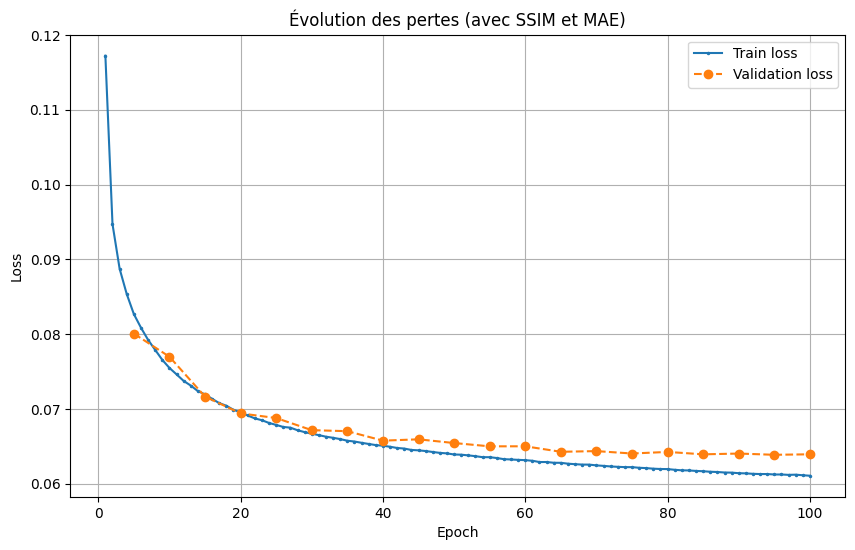

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Fichier de log et nom de l'image de sortie
log_file = "/kaggle/working/training_log_v1_ssim_mae.csv"   # ← adapté
output_image = "/kaggle/working/loss_curve_v1_ssim_mae.png" # ← cohérent

# Vérifier que le fichier existe
if not os.path.exists(log_file):
    raise FileNotFoundError(f"Le fichier {log_file} est introuvable. Vérifiez le chemin.")

# Charger les données
df = pd.read_csv(log_file)
print("Aperçu des données :")
print(df.head())

# Vérifier que les colonnes nécessaires existent
required_cols = ['epoch', 'train_loss', 'val_loss']
for col in required_cols:
    if col not in df.columns:
        raise KeyError(f"La colonne '{col}' est absente du fichier CSV. Colonnes disponibles : {list(df.columns)}")

# Créer la figure
plt.figure(figsize=(10,6))
plt.plot(df['epoch'], df['train_loss'], label='Train loss', marker='.', markersize=3)
val_data = df[df['val_loss'].notna()]
plt.plot(val_data['epoch'], val_data['val_loss'], label='Validation loss', marker='o', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Évolution des pertes (avec SSIM et MAE)')  # titre mis à jour
plt.legend()
plt.grid(True)

# Sauvegarder l'image
plt.savefig(output_image, dpi=150, bbox_inches='tight')
print(f"Courbe sauvegardée sous : {output_image}")

# Afficher le graphique
plt.show()

In [8]:
import os
from IPython.display import FileLink

# Nom de l'archive (adapté à la nouvelle version)
archive_name = "results_v1_ssim_mae.zip"

# Liste des dossiers/fichiers à inclure (chemins de la nouvelle version)
items_to_zip = [
    "/kaggle/working/checkpoints_v1_ssim_mae",
    "/kaggle/working/training_visuals_v1_ssim_mae",
    "/kaggle/working/training_log_v1_ssim_mae.csv"
]

# Filtrer les éléments qui existent vraiment (pour éviter les erreurs si certains n'ont pas encore été créés)
existing_items = [item for item in items_to_zip if os.path.exists(item)]

if existing_items:
    # Construire la commande zip
    cmd = f"zip -r {archive_name} " + " ".join(existing_items)
    os.system(cmd)
    print(f"Archive créée : {archive_name}")
    display(FileLink(archive_name))
else:
    print("Aucun fichier ou dossier trouvé à archiver.")

  adding: kaggle/working/checkpoints_v1_ssim_mae/ (stored 0%)
  adding: kaggle/working/checkpoints_v1_ssim_mae/best_model.pth (deflated 8%)
  adding: kaggle/working/checkpoints_v1_ssim_mae/latest_checkpoint.pth (deflated 9%)
  adding: kaggle/working/training_visuals_v1_ssim_mae/ (stored 0%)
  adding: kaggle/working/training_visuals_v1_ssim_mae/epoch_070.png (deflated 0%)
  adding: kaggle/working/training_visuals_v1_ssim_mae/epoch_100.png (deflated 0%)
  adding: kaggle/working/training_visuals_v1_ssim_mae/epoch_025.png (deflated 0%)
  adding: kaggle/working/training_visuals_v1_ssim_mae/epoch_080.png (deflated 0%)
  adding: kaggle/working/training_visuals_v1_ssim_mae/epoch_075.png (deflated 0%)
  adding: kaggle/working/training_visuals_v1_ssim_mae/epoch_030.png (deflated 0%)
  adding: kaggle/working/training_visuals_v1_ssim_mae/epoch_065.png (deflated 0%)
  adding: kaggle/working/training_visuals_v1_ssim_mae/epoch_090.png (deflated 0%)
  adding: kaggle/working/training_visuals_v1_ssim_ma

/kaggle/working/results_v1_ssim_mae.zip